In [60]:
import os
import numpy as np
import pickle
import glob 

# Define the path to Nikolai's data
data_path = '/home/jan/projects/CIIRC/column generation/IPM_MPNN/fac6/IF/rmp/New_IF15'

# Load all problem files from the directory
problem_files = glob.glob(os.path.join(data_path, '*.pkl'))
print(f"Found {len(problem_files)} problem files")




Found 1 problem files


In [61]:
file_path = problem_files[0]
with open(file_path, 'rb') as f:
        problem_data = pickle.load(f)
len(problem_data)

50000

In [62]:
problem_data[0]['c']

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.])

In [63]:
sizes_c

Counter({91: 25000})

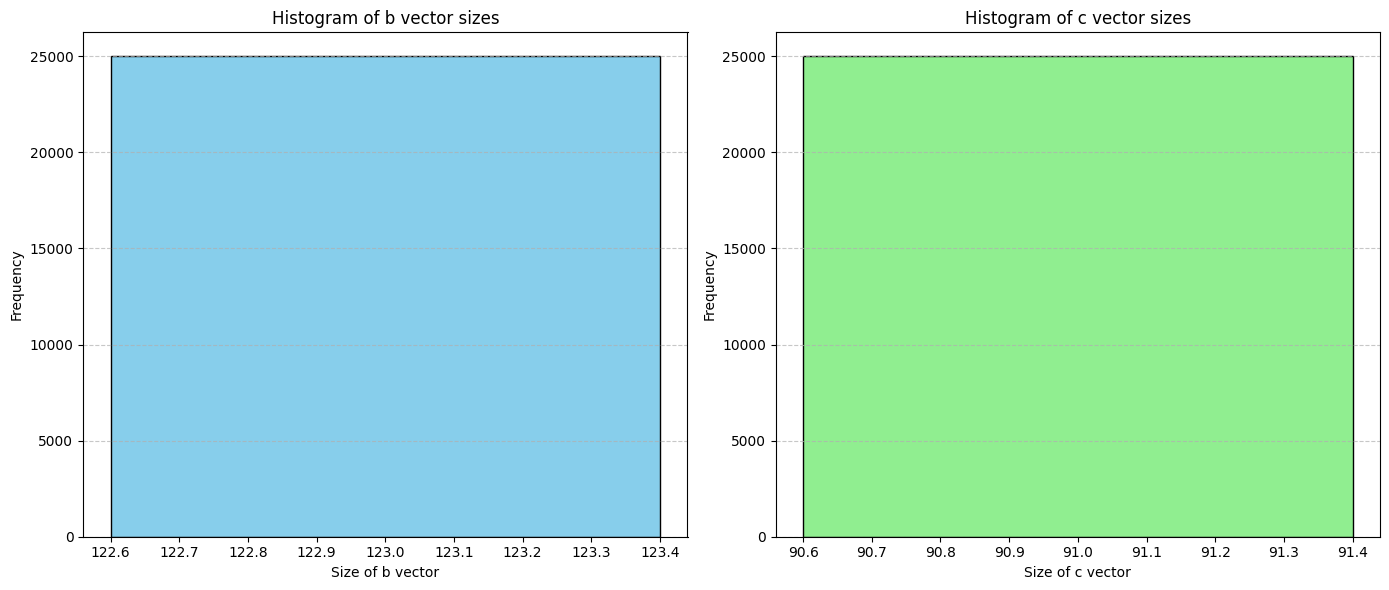

b vector sizes: {123: 25000}
c vector sizes: {91: 25000}
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}


In [59]:
from collections import Counter

sizes_b = Counter()
sizes_c = Counter()
classes = list()
for pr in problem_data:
    sizes_b[len(pr['b'])]+=1
    sizes_c[len(pr['x'])]+=1
    classes.extend(pr['x'])

import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot histogram for sizes_b
ax1.bar(sizes_b.keys(), sizes_b.values(), color='skyblue', edgecolor='black')
ax1.set_title('Histogram of b vector sizes')
ax1.set_xlabel('Size of b vector')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot histogram for sizes_c
ax2.bar(sizes_c.keys(), sizes_c.values(), color='lightgreen', edgecolor='black')
ax2.set_title('Histogram of c vector sizes')
ax2.set_xlabel('Size of c vector')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"b vector sizes: {dict(sizes_b)}")
print(f"c vector sizes: {dict(sizes_c)}")
print(set(classes))


In [54]:
set(pr['x'])

{0, 1, 2, 3, 4, 5, 6, 7}

In [ ]:
# Initialize a list to store all problems
history = []

# Load each problem file
for file_path in problem_files:
    try:
        with open(file_path, 'rb') as f:
            problem_data = pickle.load(f)
            history.append(problem_data)
        print(f"Loaded {file_path}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

print(f"Successfully loaded {len(history)} problems")

In [64]:
import torch
import gzip
import os
import pickle
from tqdm import tqdm

def save_problems(root,history,subfolder,max_problems=10000):
    os.makedirs(f'{root}/{subfolder}/raw', exist_ok=True)
    ips = []
    pkg_idx = 0
    for problem in tqdm(problem_data):
        A = problem['A']
        b = problem['b']
        c = problem['c'] # in the solver we minimize instead of maximize
        x = problem['x']
        ips.append((torch.from_numpy(A).to(torch.float), torch.from_numpy(b).to(torch.float), torch.from_numpy(c).to(torch.float),torch.from_numpy(np.array(x)))) 
        if len(ips) >= 1000:
                with gzip.open(f'{root}/{subfolder}/raw/instance_{pkg_idx}.pkl.gz', "wb") as file:
                    pickle.dump(ips, file)
                    pkg_idx += 1
                ips = []

root = '/home/jan/projects/CIIRC/column generation/IPM_MPNN/fac6/'
subfolder = 'IF'

save_problems(root,problem_data,subfolder)

100%|██████████| 50000/50000 [01:45<00:00, 472.47it/s]
